In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_clean = pd.read_csv("../data/clean/df_clean.csv")
df_clean.shape

(400916, 8)

## Observation & Prediction Window

In [3]:
observation_end = "2010-08-31"
prediction_start = "2010-09-01"
prediction_end = "2010-11-30"

In [4]:
observation_df = df_clean[
    df_clean["InvoiceDate"] <= observation_end
].copy()

prediction_df = df_clean[
    (df_clean["InvoiceDate"] >= prediction_start) &
    (df_clean["InvoiceDate"] <= prediction_end)
].copy()

print("Observation Shape :", observation_df.shape)
print("Prediction Shape  :", prediction_df.shape)

Observation Shape : (243855, 8)
Prediction Shape  : (139652, 8)


In [5]:
print(observation_df["InvoiceDate"].min())
print(observation_df["InvoiceDate"].max())

print(prediction_df["InvoiceDate"].min())
print(prediction_df["InvoiceDate"].max())

2009-12-01 07:45:00
2010-08-29 16:01:00
2010-09-01 09:25:00
2010-11-29 17:35:00


## Transaction Amount

In [6]:
observation_df["Amount"] = (
    observation_df["Quantity"] * observation_df["Price"]
)

prediction_df["Amount"] = (
    prediction_df["Quantity"] * prediction_df["Price"]
)

## Target Variable

In [7]:
target_df = (
    prediction_df
    .groupby("Customer ID", as_index=False)["Amount"]
    .sum()
    .rename(columns={"Amount": "Future_CLV"})
)

target_df.head()

,Customer ID,Future_CLV
0,12347.0,611.53
1,12348.0,222.16
2,12349.0,1402.62
3,12351.0,300.93
4,12352.0,343.80


In [8]:
print(target_df.shape)

target_df.describe()

(2868, 2)


,Customer ID,Future_CLV
count,2868.000000,2868.000000
mean,15320.649582,1038.626134
std,1690.278345,3215.214683
min,12347.000000,7.900000
25%,13867.750000,269.007500
50%,15330.500000,478.020000
75%,16787.250000,945.457500
max,18287.000000,87261.460000


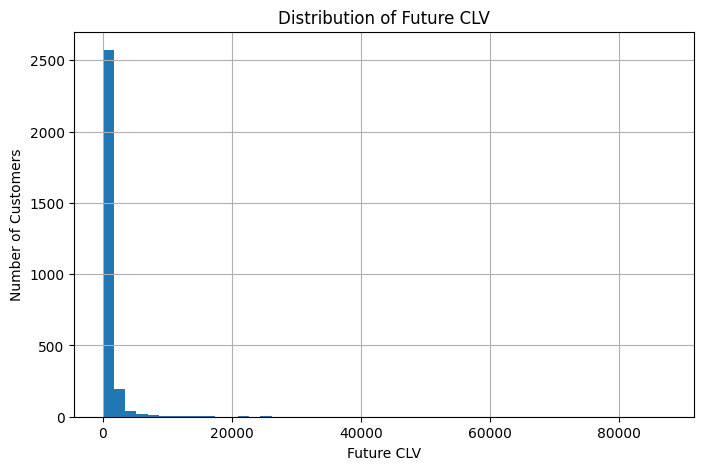

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
target_df["Future_CLV"].hist(bins=50)
plt.title("Distribution of Future CLV")
plt.xlabel("Future CLV")
plt.ylabel("Number of Customers")
plt.show()

## Customer Feature Table

In [10]:
customer_features = (
    observation_df[["Customer ID"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(customer_features.shape)

customer_features.head()

(3313, 1)


,Customer ID
0,13085.0
1,13078.0
2,15362.0
3,18102.0
4,12682.0


### Monetary value

In [11]:
monetary = (
    observation_df
    .groupby("Customer ID", as_index=False)["Amount"]
    .sum()
    .rename(columns={"Amount": "Monetary"})
)

customer_features = customer_features.merge(
    monetary,
    on="Customer ID",
    how="left"
)
customer_features.head()

,Customer ID,Monetary
0,13085.0,2017.20
1,13078.0,10849.24
2,15362.0,310.75
3,18102.0,266203.79
4,12682.0,7951.83


### Frequency

In [12]:
frequency = (
    observation_df
    .groupby("Customer ID")["Invoice"]
    .nunique()
    .reset_index()
    .rename(columns={"Invoice": "Frequency"})
)

customer_features = customer_features.merge(
    frequency,
    on="Customer ID",
    how="left"
)

In [13]:
customer_features.head()

,Customer ID,Monetary,Frequency
0,13085.0,2017.20,6
1,13078.0,10849.24,23
2,15362.0,310.75,1
3,18102.0,266203.79,77
4,12682.0,7951.83,15


In [14]:
observation_df["InvoiceDate"] = pd.to_datetime(observation_df["InvoiceDate"])

### recency

In [15]:
snapshot_date = observation_df["InvoiceDate"].max() + pd.Timedelta(days=1)

recency = (
    observation_df
    .groupby("Customer ID")["InvoiceDate"]
    .max()
    .reset_index()
)

recency["Recency"] = (
    snapshot_date - recency["InvoiceDate"]
).dt.days

recency = recency.drop(columns="InvoiceDate")

customer_features = customer_features.merge(
    recency,
    on="Customer ID",
    how="left"
)

In [16]:
customer_features.head()



,Customer ID,Monetary,Frequency,Recency
0,13085.0,2017.20,6,213
1,13078.0,10849.24,23,6
2,15362.0,310.75,1,272
3,18102.0,266203.79,77,4
4,12682.0,7951.83,15,5


In [17]:
customer_features.describe()

,Customer ID,Monetary,Frequency,Recency
count,3313.000000,3313.000000,3313.000000,3313.000000
mean,15350.076064,1640.863158,3.614247,90.034410
std,1691.608327,7146.586724,6.050088,74.168662
min,12346.000000,2.950000,1.000000,1.000000
25%,13900.000000,266.930000,1.000000,27.000000
50%,15331.000000,594.210000,2.000000,73.000000
75%,16822.000000,1400.200000,4.000000,137.000000
max,18287.000000,266203.790000,115.000000,272.000000


### Average order value

In [18]:
aov = (
    observation_df
    .groupby("Customer ID")["Amount"]
    .mean()
    .reset_index()
    .rename(columns={"Amount": "Average_Order_Value"})
)

customer_features = customer_features.merge(
    aov,
    on="Customer ID",
    how="left"
)

customer_features.head()

,Customer ID,Monetary,Frequency,Recency,Average_Order_Value
0,13085.0,2017.20,6,213,32.535484
1,13078.0,10849.24,23,6,37.802230
2,15362.0,310.75,1,272,13.510870
3,18102.0,266203.79,77,4,471.992535
4,12682.0,7951.83,15,5,23.183178


### Total Quantity

In [19]:
total_quantity = (
    observation_df
    .groupby("Customer ID")["Quantity"]
    .sum()
    .reset_index()
    .rename(columns={"Quantity": "Total_Quantity"})
)

customer_features = customer_features.merge(
    total_quantity,
    on="Customer ID",
    how="left"
)

### Unique Product

In [20]:
unique_products = (
    observation_df
    .groupby("Customer ID")["StockCode"]
    .nunique()
    .reset_index()
    .rename(columns={"StockCode": "Unique_Products"})
)

customer_features = customer_features.merge(
    unique_products,
    on="Customer ID",
    how="left"
)

### Active Month

In [21]:
active_months = (
    observation_df
    .assign(Month=observation_df["InvoiceDate"].dt.to_period("M"))
    .groupby("Customer ID")["Month"]
    .nunique()
    .reset_index()
    .rename(columns={"Month": "Active_Months"})
)

customer_features = customer_features.merge(
    active_months,
    on="Customer ID",
    how="left"
)

### Average purchace interval

In [22]:
purchase_dates = (
    observation_df
    .groupby(["Customer ID", "Invoice"])["InvoiceDate"]
    .min()
    .reset_index()
)

purchase_dates = purchase_dates.sort_values(
    ["Customer ID", "InvoiceDate"]
)

purchase_dates["Days_Between_Purchases"] = (
    purchase_dates
    .groupby("Customer ID")["InvoiceDate"]
    .diff()
    .dt.days
)

avg_purchase_interval = (
    purchase_dates
    .groupby("Customer ID")["Days_Between_Purchases"]
    .mean()
    .fillna(0)
    .reset_index()
    .rename(columns={
        "Days_Between_Purchases": "Avg_Purchase_Interval"
    })
)

customer_features = customer_features.merge(
    avg_purchase_interval,
    on="Customer ID",
    how="left"
)

In [23]:
customer_features.shape

(3313, 9)

In [24]:
customer_features.head()

,Customer ID,Monetary,Frequency,Recency,Average_Order_Value,Total_Quantity,Unique_Products,Active_Months,Avg_Purchase_Interval
0,13085.0,2017.20,6,213,32.535484,728,33,2,11.600000
1,13078.0,10849.24,23,6,37.802230,3872,82,9,11.681818
2,15362.0,310.75,1,272,13.510870,145,23,1,0.000000
3,18102.0,266203.79,77,4,471.992535,106112,268,9,3.263158
4,12682.0,7951.83,15,5,23.183178,3598,154,9,18.500000


In [25]:
customer_features.describe()

,Customer ID,Monetary,Frequency,Recency,Average_Order_Value,Total_Quantity,Unique_Products,Active_Months,Avg_Purchase_Interval
count,3313.000000,3313.000000,3313.000000,3313.000000,3313.000000,3313.000000,3313.000000,3313.000000,3313.000000
mean,15350.076064,1640.863158,3.614247,90.034410,37.398845,1066.784787,52.773015,2.494718,34.030865
std,1691.608327,7146.586724,6.050088,74.168662,237.378097,5971.071935,71.028579,1.926970,43.935249
min,12346.000000,2.950000,1.000000,1.000000,2.126786,1.000000,1.000000,1.000000,0.000000
25%,13900.000000,266.930000,1.000000,27.000000,11.456429,128.000000,15.000000,1.000000,0.000000
50%,15331.000000,594.210000,2.000000,73.000000,17.370119,323.000000,32.000000,2.000000,19.500000
75%,16822.000000,1400.200000,4.000000,137.000000,25.379375,820.000000,66.000000,3.000000,52.600000
max,18287.000000,266203.790000,115.000000,272.000000,10953.500000,220600.000000,1269.000000,9.000000,262.000000


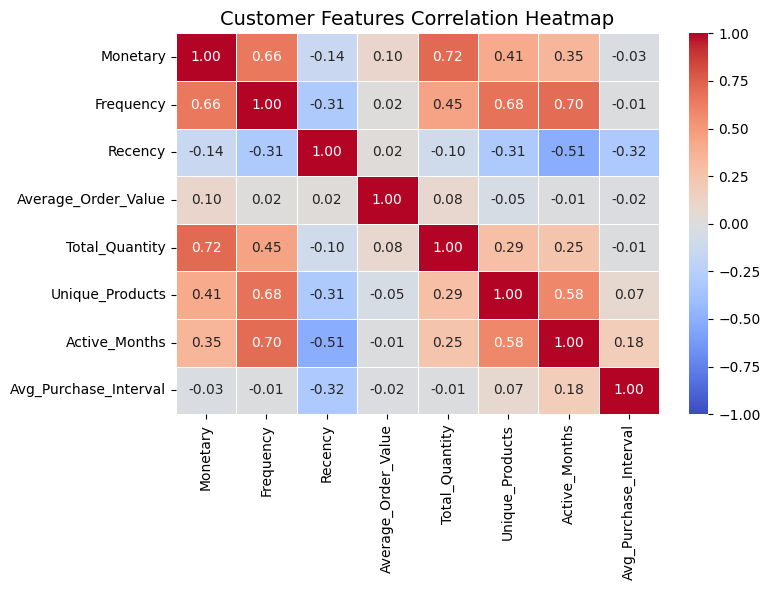

In [26]:
plt.figure(figsize=(8, 6))

# Compute correlation matrix for numeric columns
corr_matrix = customer_features.drop(columns=["Customer ID"]).corr()

# Plot heatmap
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)

plt.title("Customer Features Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

## Creating Model Dataset

In [27]:
model_df = customer_features.merge(
    target_df,
    on="Customer ID",
    how="left"
)

model_df["Future_CLV"] = model_df["Future_CLV"].fillna(0)

print("Modeling dataset shape:", model_df.shape)
print("Customers with zero future CLV:",
      (model_df["Future_CLV"] == 0).sum())

Modeling dataset shape: (3313, 10)
Customers with zero future CLV: 1389


In [28]:
 model_df.head()

,Customer ID,Monetary,Frequency,Recency,Average_Order_Value,Total_Quantity,Unique_Products,Active_Months,Avg_Purchase_Interval,Future_CLV
0,13085.0,2017.20,6,213,32.535484,728,33,2,11.600000,0.00
1,13078.0,10849.24,23,6,37.802230,3872,82,9,11.681818,4671.70
2,15362.0,310.75,1,272,13.510870,145,23,1,0.000000,302.33
3,18102.0,266203.79,77,4,471.992535,106112,268,9,3.263158,52288.07
4,12682.0,7951.83,15,5,23.183178,3598,154,9,18.500000,2718.57


In [29]:
model_df.isnull().sum()

Customer ID              0
Monetary                 0
Frequency                0
Recency                  0
Average_Order_Value      0
Total_Quantity           0
Unique_Products          0
Active_Months            0
Avg_Purchase_Interval    0
Future_CLV               0
dtype: int64

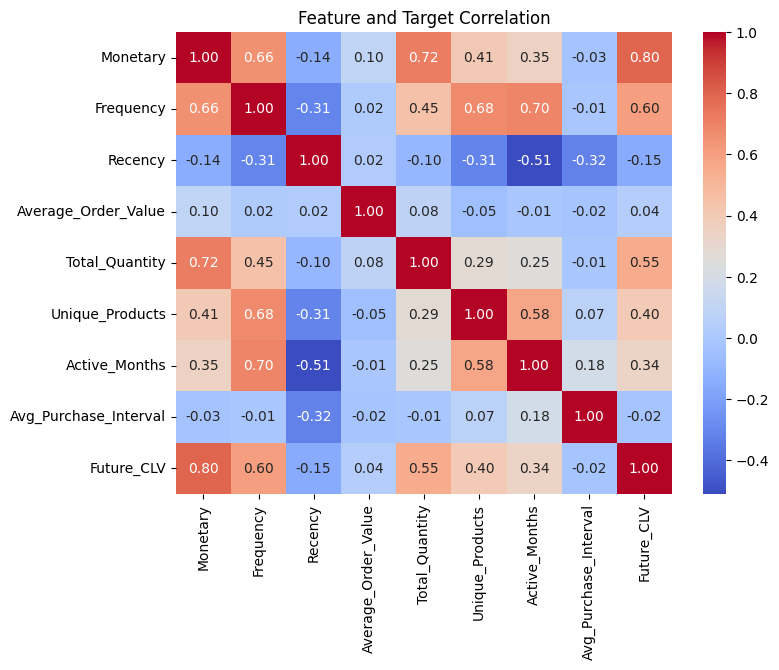

In [30]:
correlation = model_df.drop(columns=["Customer ID"]).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature and Target Correlation")
plt.show()

### Outlier Analysis

In [31]:
feature_cols = [
    "Monetary",
    "Frequency",
    "Recency",
    "Average_Order_Value",
    "Total_Quantity",
    "Unique_Products",
    "Active_Months",
    "Avg_Purchase_Interval",
    "Future_CLV"
]

model_df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Monetary,3313.0,1640.863158,7146.586724,2.950000,266.930000,594.210000,1400.200000,266203.79
Frequency,3313.0,3.614247,6.050088,1.000000,1.000000,2.000000,4.000000,115.00
Recency,3313.0,90.034410,74.168662,1.000000,27.000000,73.000000,137.000000,272.00
Average_Order_Value,3313.0,37.398845,237.378097,2.126786,11.456429,17.370119,25.379375,10953.50
Total_Quantity,3313.0,1066.784787,5971.071935,1.000000,128.000000,323.000000,820.000000,220600.00
Unique_Products,3313.0,52.773015,71.028579,1.000000,15.000000,32.000000,66.000000,1269.00
Active_Months,3313.0,2.494718,1.926970,1.000000,1.000000,2.000000,3.000000,9.00
Avg_Purchase_Interval,3313.0,34.030865,43.935249,0.000000,0.000000,19.500000,52.600000,262.00
Future_CLV,3313.0,717.969572,2867.610644,0.000000,0.000000,200.750000,673.510000,87261.46


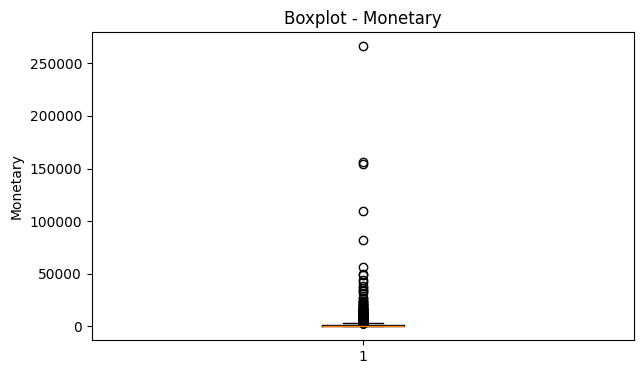

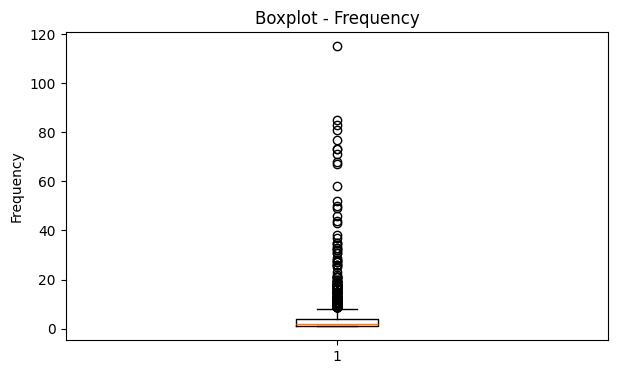

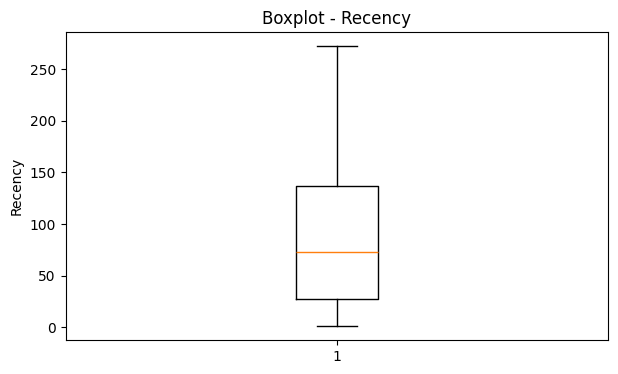

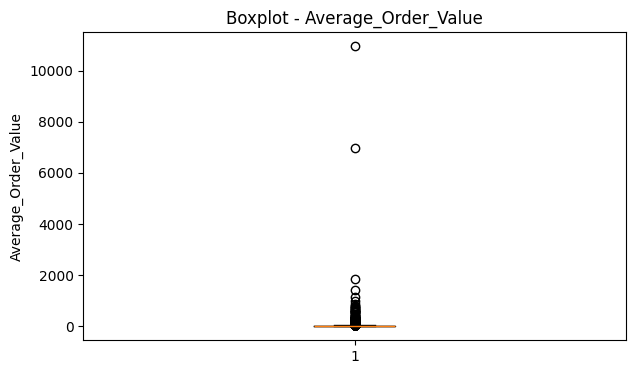

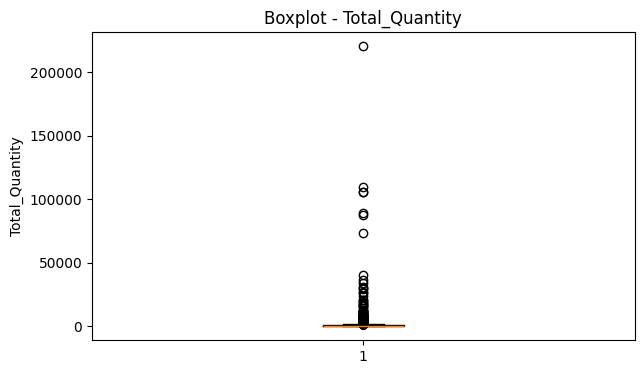

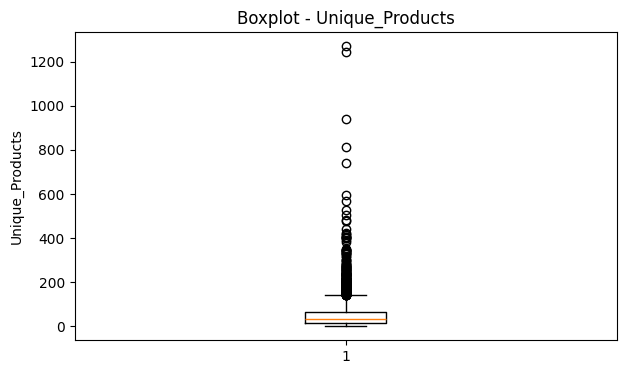

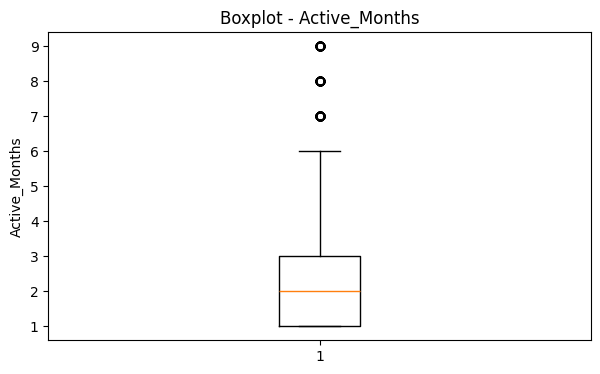

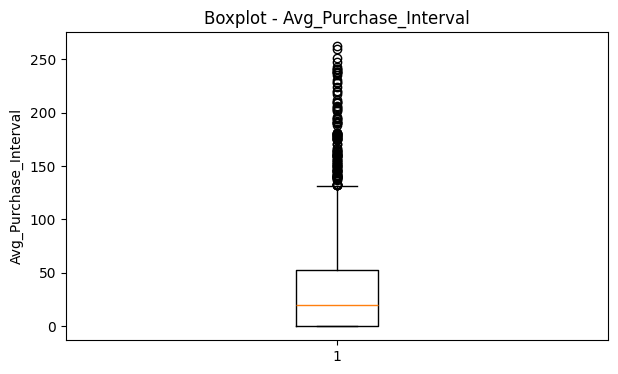

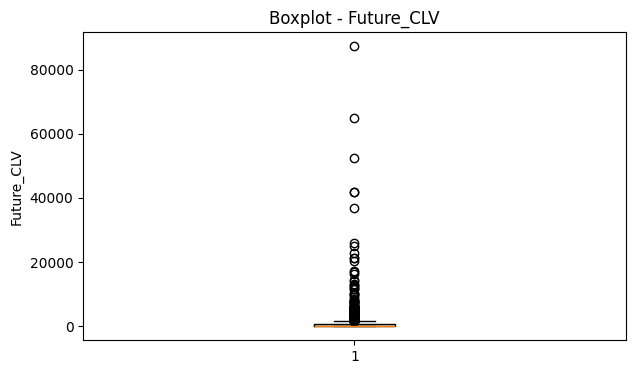

In [32]:
import matplotlib.pyplot as plt

for feature in feature_cols:
    plt.figure(figsize=(7, 4))
    plt.boxplot(model_df[feature].dropna())
    plt.title(f"Boxplot - {feature}")
    plt.ylabel(feature)
    plt.show()

In [33]:
outlier_summary = []

for feature in feature_cols:
    Q1 = model_df[feature].quantile(0.25)
    Q3 = model_df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (model_df[feature] < lower_bound) |
        (model_df[feature] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outliers,
        "Outlier_%": round(outliers / len(model_df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
0,Monetary,266.930000,1400.200000,-1432.975000,3100.105000,307,9.27
1,Frequency,1.000000,4.000000,-3.500000,8.500000,243,7.33
2,Recency,27.000000,137.000000,-138.000000,302.000000,0,0.00
3,Average_Order_Value,11.456429,25.379375,-9.427991,46.263795,368,11.11
4,Total_Quantity,128.000000,820.000000,-910.000000,1858.000000,304,9.18
5,Unique_Products,15.000000,66.000000,-61.500000,142.500000,242,7.30
6,Active_Months,1.000000,3.000000,-2.000000,6.000000,187,5.64
7,Avg_Purchase_Interval,0.000000,52.600000,-78.900000,131.500000,125,3.77
8,Future_CLV,0.000000,673.510000,-1010.265000,1683.775000,271,8.18


## Prepare Features and Target

In [34]:
X = model_df.drop(columns=["Customer ID", "Future_CLV"] )
y = model_df["Future_CLV"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3313, 8)
y shape: (3313,)


In [35]:
from sklearn.model_selection import train_test_split

X = model_df.drop(columns=["Customer ID", "Future_CLV"])
y = model_df["Future_CLV"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 2650
Testing samples : 663


In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Mean baseline
mean_prediction = np.full(
    len(y_test),
    y_train.mean()
)

# Median baseline
median_prediction = np.full(
    len(y_test),
    y_train.median()
)

mean_mae = mean_absolute_error(y_test, mean_prediction)
mean_rmse = np.sqrt(mean_squared_error(y_test, mean_prediction))

median_mae = mean_absolute_error(y_test, median_prediction)
median_rmse = np.sqrt(mean_squared_error(y_test, median_prediction))

print("Mean Baseline")
print("MAE :", round(mean_mae, 2))
print("RMSE:", round(mean_rmse, 2))

print("\nMedian Baseline")
print("MAE :", round(median_mae, 2))
print("RMSE:", round(median_rmse, 2))

Mean Baseline
MAE : 955.96
RMSE: 3915.39

Median Baseline
MAE : 820.43
RMSE: 3964.1


In [37]:
model_df

,Customer ID,Monetary,Frequency,Recency,Average_Order_Value,Total_Quantity,Unique_Products,Active_Months,Avg_Purchase_Interval,Future_CLV
0,13085.0,2017.20,6,213,32.535484,728,33,2,11.600000,0.00
1,13078.0,10849.24,23,6,37.802230,3872,82,9,11.681818,4671.70
2,15362.0,310.75,1,272,13.510870,145,23,1,0.000000,302.33
3,18102.0,266203.79,77,4,471.992535,106112,268,9,3.263158,52288.07
4,12682.0,7951.83,15,5,23.183178,3598,154,9,18.500000,2718.57
...,...,...,...,...,...,...,...,...,...,...
3308,15936.0,171.62,1,1,15.601818,99,11,1,0.000000,111.17
3309,15074.0,359.66,1,1,16.348182,364,22,1,0.000000,457.80
3310,15166.0,167.16,1,1,13.930000,140,12,1,0.000000,0.00
3311,13922.0,423.20,1,1,32.553846,235,13,1,0.000000,269.75


In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_features="sqrt"
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("Random Forest Baseline")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))

Random Forest Baseline
MAE : 644.12
RMSE: 2639.68


## Prediction Diagnostics

In [39]:
results = pd.DataFrame({
    "Actual_CLV": y_test.values,
    "Predicted_CLV": rf_predictions
})

results["Error"] = (
    results["Actual_CLV"] - results["Predicted_CLV"]
)

results["Absolute_Error"] = (
    results["Error"].abs()
)

results["Percentage_Error"] = (
    results["Absolute_Error"] /
    results["Actual_CLV"].clip(lower=1)
) * 100

results.describe()

,Actual_CLV,Predicted_CLV,Error,Absolute_Error,Percentage_Error
count,663.000000,663.000000,663.000000,663.000000,6.630000e+02
mean,839.435505,800.604197,38.831309,644.115567,1.935710e+04
std,3915.398941,2046.163754,2641.385501,2561.818873,7.132769e+04
min,0.000000,23.469100,-15642.447033,0.273200,6.212650e-02
25%,0.000000,192.206217,-299.795550,130.802805,4.108392e+01
50%,195.350000,353.335900,-114.874433,259.287700,1.002580e+02
75%,665.580000,686.946317,153.535162,528.726632,2.117692e+04
max,87261.460000,29465.405933,57796.054067,57796.054067,1.564245e+06


In [40]:
results.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)


,Actual_CLV,Predicted_CLV,Error,Absolute_Error,Percentage_Error
224,87261.46,29465.405933,57796.054067,57796.054067,6.623320e+01
339,0.00,15642.447033,-15642.447033,15642.447033,1.564245e+06
459,17367.10,2861.771667,14505.328333,14505.328333,8.352188e+01
488,26058.70,12941.206267,13117.493733,13117.493733,5.033825e+01
562,13238.70,1399.183133,11839.516867,11839.516867,8.943111e+01
275,4796.88,14882.216567,-10085.336567,10085.336567,2.102478e+02
338,0.00,5485.872100,-5485.872100,5485.872100,5.485872e+05
360,500.00,5296.980967,-4796.980967,4796.980967,9.593962e+02
102,11483.40,6780.869667,4702.530333,4702.530333,4.095068e+01
222,7848.92,3419.725633,4429.194367,4429.194367,5.643062e+01


In [41]:
results.sort_values(
    "Actual_CLV",
    ascending=False
).head(10)

,Actual_CLV,Predicted_CLV,Error,Absolute_Error,Percentage_Error
224,87261.46,29465.405933,57796.054067,57796.054067,66.233196
488,26058.70,12941.206267,13117.493733,13117.493733,50.338251
632,24939.25,25932.538300,-993.288300,993.288300,3.982831
459,17367.10,2861.771667,14505.328333,14505.328333,83.521879
562,13238.70,1399.183133,11839.516867,11839.516867,89.431114
92,11673.50,14381.180267,-2707.680267,2707.680267,23.195102
102,11483.40,6780.869667,4702.530333,4702.530333,40.950680
87,9917.09,8429.202067,1487.887933,1487.887933,15.003271
516,9158.73,7183.385267,1975.344733,1975.344733,21.567889
222,7848.92,3419.725633,4429.194367,4429.194367,56.430622


In [42]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Monetary,0.283303
4,Total_Quantity,0.209420
1,Frequency,0.156984
5,Unique_Products,0.129365
3,Average_Order_Value,0.065081
7,Avg_Purchase_Interval,0.062356
6,Active_Months,0.047621
2,Recency,0.045870


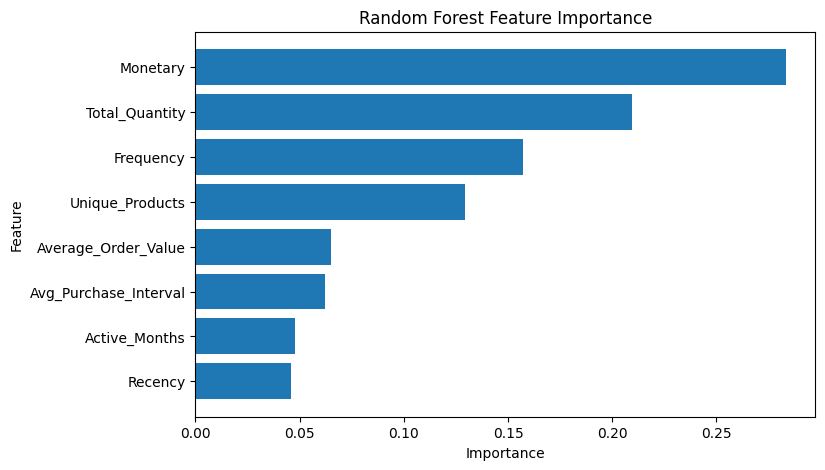

In [43]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [44]:
import numpy as np

X_train_log = X_train.copy()
X_test_log = X_test.copy()

log_features = [
    "Monetary",
    "Frequency",
    "Average_Order_Value",
    "Total_Quantity",
    "Unique_Products",
    "Avg_Purchase_Interval"
]

for feature in log_features:
    X_train_log[feature] = np.log1p(X_train_log[feature])
    X_test_log[feature] = np.log1p(X_test_log[feature])

In [45]:
X_train_log

,Monetary,Frequency,Recency,Average_Order_Value,Total_Quantity,Unique_Products,Active_Months,Avg_Purchase_Interval
2601,5.869692,0.693147,103,2.880108,5.424950,3.091042,1,0.000000
1447,6.150155,1.098612,202,3.350502,5.697093,2.890372,1,0.000000
2126,7.675588,1.791759,32,3.033139,6.779922,4.394449,4,3.433987
2321,5.399067,0.693147,132,4.710431,4.691348,1.098612,1,0.000000
862,7.194459,1.609438,165,3.814800,6.797940,3.178054,4,3.433987
...,...,...,...,...,...,...,...,...
1095,6.230895,1.098612,83,2.276754,6.335054,3.931826,2,4.962845
1130,6.679436,1.386294,54,2.582394,5.762051,4.043051,3,4.442651
1294,6.049026,0.693147,214,2.778597,5.351858,3.367296,1,0.000000
860,5.781515,0.693147,257,3.054149,4.820282,2.833213,1,0.000000


In [46]:
rf_log = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_features="sqrt"
)

rf_log.fit(X_train_log, y_train)

log_predictions = rf_log.predict(X_test_log)

log_mae = mean_absolute_error(
    y_test,
    log_predictions
)

log_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        log_predictions
    )
)

print("Random Forest + Log Features")
print("MAE :", round(log_mae, 2))
print("RMSE:", round(log_rmse, 2))

Random Forest + Log Features
MAE : 641.85
RMSE: 2609.34


In [47]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, log_predictions)

print("R² Score:", r2)

R² Score: 0.5552007666183754


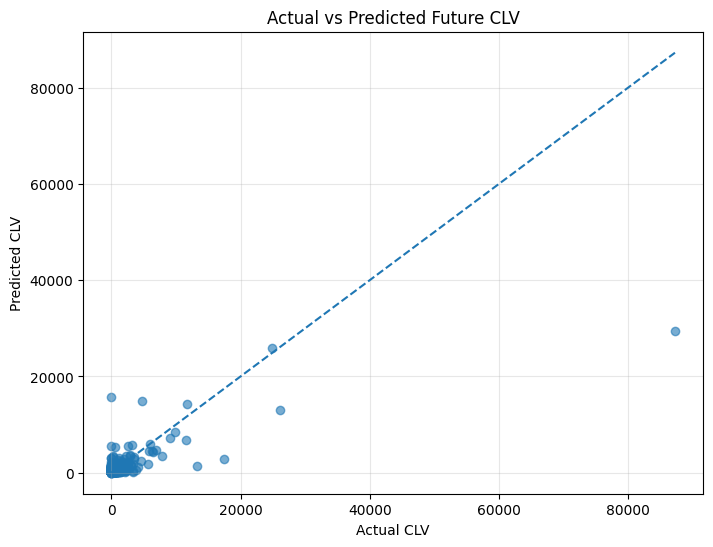

In [48]:
plt.figure(figsize=(8, 6))

plt.scatter(
    results["Actual_CLV"],
    results["Predicted_CLV"],
    alpha=0.6
)

# Perfect prediction line
max_value = max(
    results["Actual_CLV"].max(),
    results["Predicted_CLV"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs Predicted Future CLV")
plt.grid(alpha=0.3)

plt.show()

In [49]:
results = pd.DataFrame({
    "Actual_CLV": y_test.values,
    "Predicted_CLV": log_predictions
})

results["Error"] = (
    results["Actual_CLV"] - results["Predicted_CLV"]
)

results["Absolute_Error"] = (
    results["Error"].abs()
)

results["Percentage_Error"] = (
    results["Absolute_Error"] /
    results["Actual_CLV"].clip(lower=1)
) * 100

results.describe()

,Actual_CLV,Predicted_CLV,Error,Absolute_Error,Percentage_Error
count,663.000000,663.000000,663.000000,663.000000,6.630000e+02
mean,839.435505,804.584279,34.851226,641.850542,1.939924e+04
std,3915.398941,2076.595706,2611.074679,2531.073486,7.161204e+04
min,0.000000,24.348867,-15660.946133,0.294667,1.273904e-01
25%,0.000000,191.981617,-308.022767,130.025100,4.098009e+01
50%,195.350000,352.183667,-116.109033,255.818033,9.968450e+01
75%,665.580000,684.790568,158.221850,531.036817,2.140031e+04
max,87261.460000,30295.302500,56966.157500,56966.157500,1.566095e+06


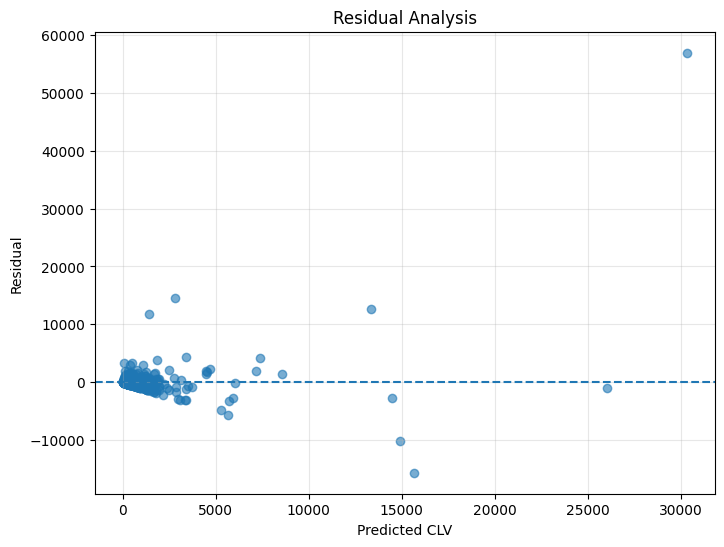

In [50]:
results["Residual"] = (
    results["Actual_CLV"] - results["Predicted_CLV"]
)

plt.figure(figsize=(8, 6))

plt.scatter(
    results["Predicted_CLV"],
    results["Residual"],
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted CLV")
plt.ylabel("Residual")
plt.title("Residual Analysis")
plt.grid(alpha=0.3)

plt.show()

In [51]:
import xgboost as xgb

print(xgb.__version__)

1.7.6


In [52]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_log, y_train)

xgb_predictions = xgb_model.predict(X_test_log)

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("XGBoost Baseline")
print("MAE :", round(xgb_mae, 2))
print("RMSE:", round(xgb_rmse, 2))
print("R²  :", round(xgb_r2, 4))

XGBoost Baseline
MAE : 663.78
RMSE: 2282.51
R²  : 0.6596


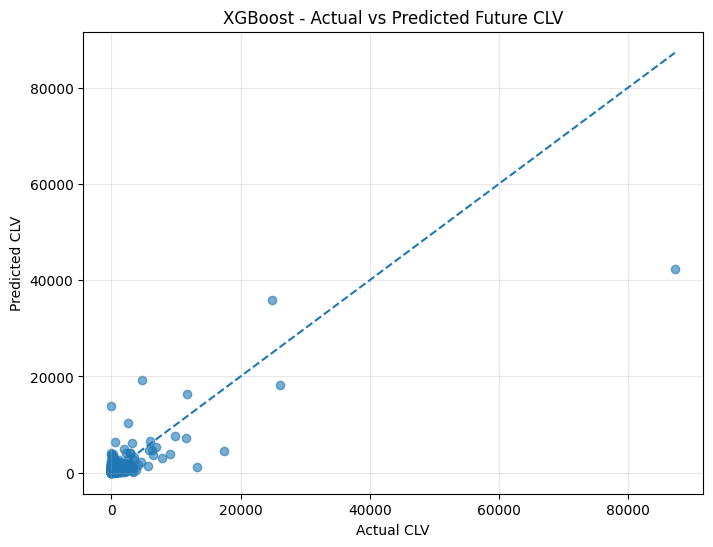

In [54]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    xgb_predictions,
    alpha=0.6
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("XGBoost - Actual vs Predicted Future CLV")
plt.grid(alpha=0.3)

plt.show()

In [55]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from xgboost import XGBRegressor

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [200, 300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 2, 5, 10]
}

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=40,
    scoring="neg_mean_absolute_error",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_log, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...state=42, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that ca

In [56]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV MAE:")
print(-random_search.best_score_)

Best Parameters:
{'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.7}

Best CV MAE:
526.7899225603096


In [57]:
best_xgb = random_search.best_estimator_

In [58]:
tuned_predictions = best_xgb.predict(X_test_log)

tuned_mae = mean_absolute_error(
    y_test,
    tuned_predictions
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_predictions
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_predictions
)

print("Tuned XGBoost")
print("MAE :", round(tuned_mae, 2))
print("RMSE:", round(tuned_rmse, 2))
print("R²  :", round(tuned_r2, 4))

Tuned XGBoost
MAE : 616.57
RMSE: 2640.58
R²  : 0.5445


In [59]:
tuned_results = pd.DataFrame({
    "Actual_CLV": y_test.values,
    "Predicted_CLV": tuned_predictions
})

tuned_results["Error"] = (
    tuned_results["Actual_CLV"] -
    tuned_results["Predicted_CLV"]
)

tuned_results["Absolute_Error"] = (
    tuned_results["Error"].abs()
)

In [60]:
tuned_results.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Actual_CLV,Predicted_CLV,Error,Absolute_Error
224,87261.46,28808.240234,58453.219766,58453.219766
488,26058.70,9899.956055,16158.743945,16158.743945
459,17367.10,2761.289795,14605.810205,14605.810205
562,13238.70,1506.691895,11732.008105,11732.008105
339,0.00,11597.858398,-11597.858398,11597.858398
102,11483.40,4393.500977,7089.899023,7089.899023
275,4796.88,10489.266602,-5692.386602,5692.386602
222,7848.92,2719.237061,5129.682939,5129.682939
188,5725.11,1097.042480,4628.067520,4628.067520
516,9158.73,4739.667969,4419.062031,4419.062031


In [61]:
tuned_results.sort_values(
    "Actual_CLV",
    ascending=False
).head(10)

,Actual_CLV,Predicted_CLV,Error,Absolute_Error
224,87261.46,28808.240234,58453.219766,58453.219766
488,26058.70,9899.956055,16158.743945,16158.743945
632,24939.25,23999.164062,940.085938,940.085938
459,17367.10,2761.289795,14605.810205,14605.810205
562,13238.70,1506.691895,11732.008105,11732.008105
92,11673.50,10710.256836,963.243164,963.243164
102,11483.40,4393.500977,7089.899023,7089.899023
87,9917.09,5991.400879,3925.689121,3925.689121
516,9158.73,4739.667969,4419.062031,4419.062031
222,7848.92,2719.237061,5129.682939,5129.682939


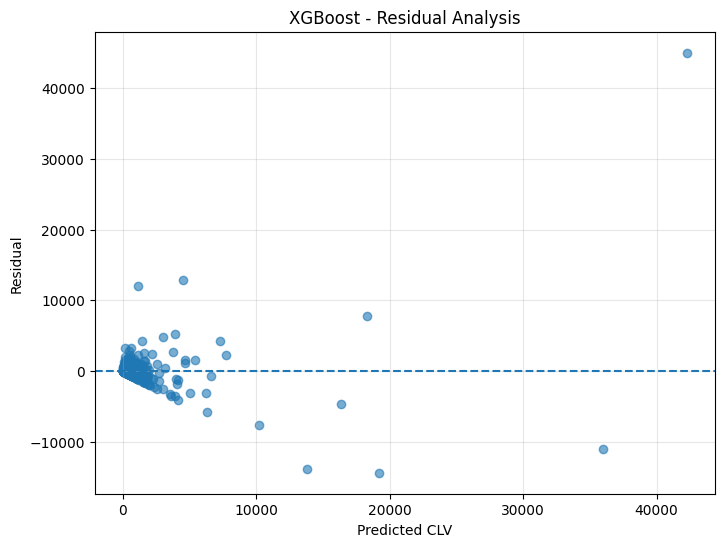

In [62]:
residuals = y_test - xgb_predictions

plt.figure(figsize=(8, 6))

plt.scatter(
    xgb_predictions,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted CLV")
plt.ylabel("Residual")
plt.title("XGBoost - Residual Analysis")
plt.grid(alpha=0.3)

plt.show()

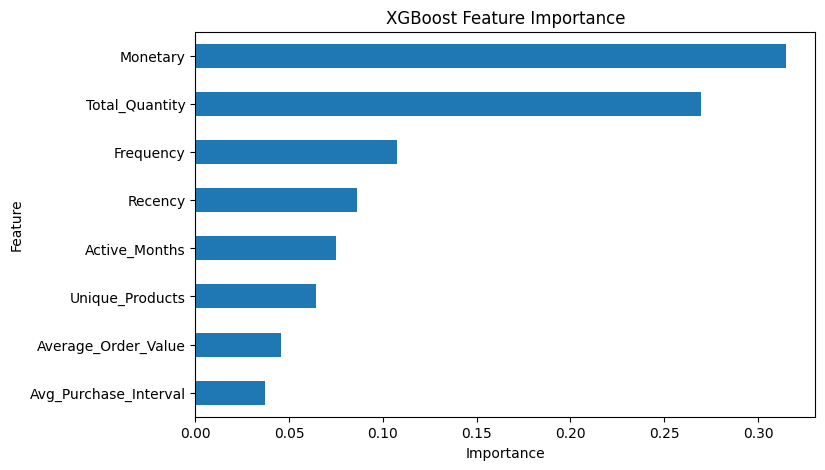

In [63]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))

importance.plot(kind="barh")

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [64]:
# Features used by the model
X_customer = customer_features[X_train.columns]

# Predict Future CLV
customer_features["Predicted_Future_CLV"] = xgb_model.predict(X_customer)

customer_features.head()

,Customer ID,Monetary,Frequency,Recency,Average_Order_Value,Total_Quantity,Unique_Products,Active_Months,Avg_Purchase_Interval,Predicted_Future_CLV
0,13085.0,2017.20,6,213,32.535484,728,33,2,11.600000,42217.683594
1,13078.0,10849.24,23,6,37.802230,3872,82,9,11.681818,58010.265625
2,15362.0,310.75,1,272,13.510870,145,23,1,0.000000,21178.955078
3,18102.0,266203.79,77,4,471.992535,106112,268,9,3.263158,60847.082031
4,12682.0,7951.83,15,5,23.183178,3598,154,9,18.500000,61156.343750


In [65]:
high_value_customers = (
    customer_features[
        ["Customer ID", "Monetary", "Frequency",
         "Recency", "Predicted_Future_CLV"]
    ]
    .sort_values(
        "Predicted_Future_CLV",
        ascending=False
    )
)

high_value_customers.head(10)

,Customer ID,Monetary,Frequency,Recency,Predicted_Future_CLV
210,12835.0,5668.02,38,4,61293.355469
278,14258.0,16247.02,13,4,61293.355469
259,17576.0,3308.32,15,4,61293.355469
843,13047.0,4558.74,12,4,61279.812500
433,12471.0,11733.63,32,4,61279.812500
64,12836.0,2776.37,9,4,61279.812500
294,18061.0,3205.65,14,4,61279.812500
2185,14221.0,2761.60,7,4,61258.824219
1883,17338.0,2451.65,5,4,61258.824219
1772,17663.0,2699.99,7,4,61258.824219


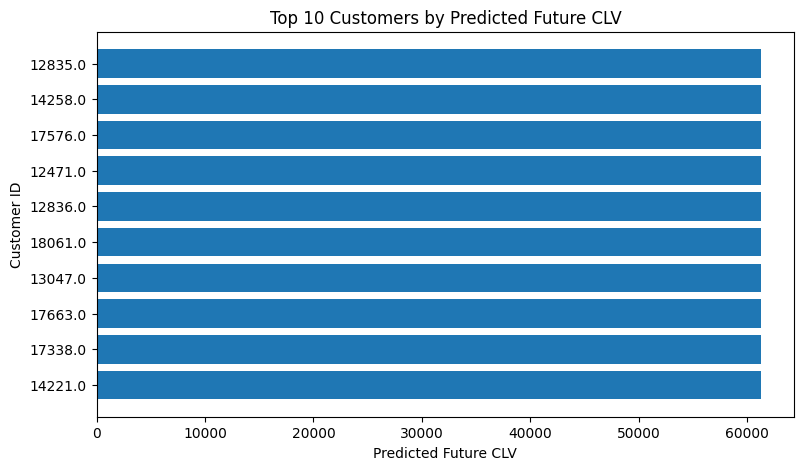

In [66]:
top_10 = high_value_customers.head(10).sort_values(
    "Predicted_Future_CLV"
)

plt.figure(figsize=(9, 5))

plt.barh(
    top_10["Customer ID"].astype(str),
    top_10["Predicted_Future_CLV"]
)

plt.xlabel("Predicted Future CLV")
plt.ylabel("Customer ID")
plt.title("Top 10 Customers by Predicted Future CLV")

plt.show()

In [67]:
print("Unique predicted CLV values:",
      customer_features["Predicted_Future_CLV"].nunique())

print("\nPrediction range:")
print(customer_features["Predicted_Future_CLV"].describe())

print("\nTop 20 predictions:")
print(
    customer_features[
        ["Customer ID", "Monetary", "Frequency",
         "Recency", "Predicted_Future_CLV"]
    ]
    .sort_values("Predicted_Future_CLV", ascending=False)
    .head(20)
)

Unique predicted CLV values: 1377

Prediction range:
count     3313.000000
mean     27873.193359
std      11933.095703
min        -38.554188
25%      21151.576172
50%      22631.656250
75%      37163.234375
max      61293.355469
Name: Predicted_Future_CLV, dtype: float64

Top 20 predictions:
      Customer ID  Monetary  Frequency  Recency  Predicted_Future_CLV
210       12835.0   5668.02         38        4          61293.355469
278       14258.0  16247.02         13        4          61293.355469
259       17576.0   3308.32         15        4          61293.355469
843       13047.0   4558.74         12        4          61279.812500
433       12471.0  11733.63         32        4          61279.812500
64        12836.0   2776.37          9        4          61279.812500
294       18061.0   3205.65         14        4          61279.812500
2185      14221.0   2761.60          7        4          61258.824219
1883      17338.0   2451.65          5        4          61258.824219
1772   

In [68]:
customer_features["Predicted_Future_CLV"] = (
    customer_features["Predicted_Future_CLV"].clip(lower=0)
)

In [69]:
high_value_customers = (
    customer_features[
        ["Customer ID", "Monetary", "Frequency",
         "Recency", "Predicted_Future_CLV"]
    ]
    .sort_values("Predicted_Future_CLV", ascending=False)
)

high_value_customers.head(10)

,Customer ID,Monetary,Frequency,Recency,Predicted_Future_CLV
210,12835.0,5668.02,38,4,61293.355469
278,14258.0,16247.02,13,4,61293.355469
259,17576.0,3308.32,15,4,61293.355469
843,13047.0,4558.74,12,4,61279.812500
433,12471.0,11733.63,32,4,61279.812500
64,12836.0,2776.37,9,4,61279.812500
294,18061.0,3205.65,14,4,61279.812500
2185,14221.0,2761.60,7,4,61258.824219
1883,17338.0,2451.65,5,4,61258.824219
1772,17663.0,2699.99,7,4,61258.824219


In [70]:
customer_features["CLV_Segment"] = pd.qcut(
    customer_features["Predicted_Future_CLV"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"],
    duplicates="drop"
)

customer_features[
    ["Customer ID", "Predicted_Future_CLV", "CLV_Segment"]
].head()

,Customer ID,Predicted_Future_CLV,CLV_Segment
0,13085.0,42217.683594,High Value
1,13078.0,58010.265625,High Value
2,15362.0,21178.955078,Low Value
3,18102.0,60847.082031,High Value
4,12682.0,61156.343750,High Value


In [71]:
segment_counts = customer_features["CLV_Segment"].value_counts()

segment_counts

CLV_Segment
Low Value       1111
Medium Value    1105
High Value      1097
Name: count, dtype: int64

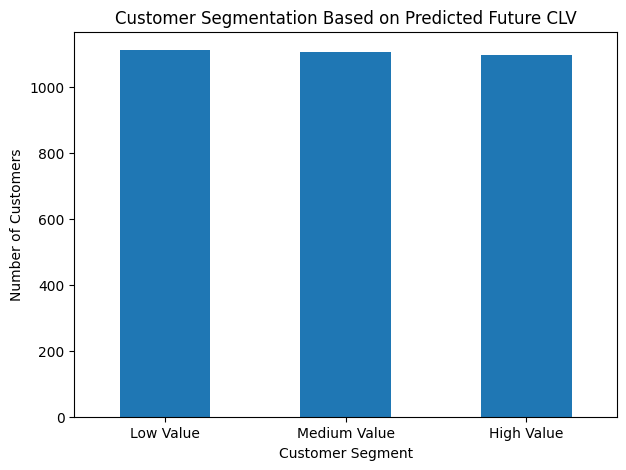

In [72]:
plt.figure(figsize=(7, 5))

segment_counts.plot(
    kind="bar"
)

plt.title("Customer Segmentation Based on Predicted Future CLV")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()